# REV1-03 — Event-Window SPI sebagai Diagnostik Defisit Presipitasi — SEMHAS v4

## Tujuan

Notebook ini menambahkan **Standardized Precipitation Index (SPI)** pada sisi pasokan air untuk setiap *grid-cell flash-drought start* yang sudah dideteksi oleh benchmark RZSM/M2A.

**Notebook ini tidak mendeteksi ulang flash drought.** Inventori FD tetap berasal dari RZSM. SPI hanya digunakan untuk menjawab:

> Apakah selama fase *rapid development* suatu FD terjadi defisit presipitasi yang besar dibanding klimatologi pada grid, musim, dan panjang perkembangan yang sama?

### Dasar metode

Christian et al. (2021) menghitung akumulasi presipitasi selama *time frame of flash drought development*, lalu menghitung SPI terhadap klimatologi presipitasi pada jendela waktu yang sama. Mereka menggunakan `SPI <= -1` sebagai ambang anomali presipitasi negatif yang besar.

Pada detector RZSM penelitian ini:

- `t0` = baseline/event start terakhir sebelum penurunan cepat, dengan RZSM masih memenuhi kondisi awal P40;
- `crossing_index_at_start` = pentad pertama ketika RZSM mencapai `<P20`;
- `onset_time_pentads = crossing_index - t0`.

Karena `onset_time_pentads` menyatakan **jumlah interval** dari baseline sampai crossing, akumulasi presipitasi utama dihitung pada:

`[t0+1, ..., crossing]`

atau tepat sebanyak `onset_time_pentads` pentad.

Notebook melakukan audit eksplisit bahwa:

`crossing_index_at_start - time_index == onset_time_pentads`

untuk seluruh event sebelum SPI dihitung.

### Periode

- Inventori FD yang dianalisis: **1996–2024**.
- Klimatologi SPI: **1995–2024 (30 tahun lengkap)**.
- File presipitasi 2025 tetap dimuat hanya untuk menyelesaikan jendela lintas-tahun dari event akhir 2024.
- Pentad 73 tahun 2025 yang missing **tidak diimputasi** dan tidak digunakan dalam klimatologi utama.

### Interpretasi

- SPI di sini adalah **event-window SPI**, bukan SPI bulanan tetap seperti SPI-1 atau SPI-3.
- `SPI <= -1` dibaca sebagai **signature defisit presipitasi yang kuat selama rapid development**.
- SPI adalah diagnostik meteorologis pasca-deteksi, **bukan dasar definisi FD dan bukan bukti atribusi kausal**.
- Analisis atmospheric demand pada skripsi tetap menggunakan VPD dan T2m yang sudah ada pada REV1-01/REV1-02.


In [1]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.special import gammainc
from scipy.stats import norm

warnings.filterwarnings("once")

# ============================================================
# PATH & PARAMETER
# ============================================================

BASE = Path(r"D:\ERA5_LAND")

DETECTION_FILE = (
    BASE / "output_fd_03b_sensitivity"
    / "fd_detection_M2A_1995_2025_indonesia.nc"
)

EVENT_DIR = BASE / "output_fd_REV1_01_event_level_drivers"
EVENT_PARQUET = EVENT_DIR / "event_level_driver_table_RAW.parquet"
EVENT_CSV_GZ = EVENT_DIR / "event_level_driver_table_RAW.csv.gz"

PRECIP_DIR = (
    BASE / "output_fd_04_drivers"
    / "yearly_pentad"
)

OUTPUT_DIR = BASE / "output_fd_REV1_03_SPI"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_START = 1996
ANALYSIS_END = 2024

CLIM_START = 1995
CLIM_END = 2024
CLIM_YEARS = np.arange(CLIM_START, CLIM_END + 1)

# File 2025 tetap dimuat untuk jendela event akhir 2024 yang menyeberang tahun.
LOAD_START = 1995
LOAD_END = 2025

SPI_THRESHOLD = -1.0
MIN_CLIM_SAMPLES = 25
PROB_EPS = 1e-7

print("Detection :", DETECTION_FILE)
print("Event dir :", EVENT_DIR)
print("Precip dir:", PRECIP_DIR)
print("Output    :", OUTPUT_DIR)
print("Climate   :", CLIM_START, "-", CLIM_END, f"({len(CLIM_YEARS)} tahun lengkap)")
print("Load data :", LOAD_START, "-", LOAD_END)


Detection : D:\ERA5_LAND\output_fd_03b_sensitivity\fd_detection_M2A_1995_2025_indonesia.nc
Event dir : D:\ERA5_LAND\output_fd_REV1_01_event_level_drivers
Precip dir: D:\ERA5_LAND\output_fd_04_drivers\yearly_pentad
Output    : D:\ERA5_LAND\output_fd_REV1_03_SPI
Climate   : 1995 - 2024 (30 tahun lengkap)
Load data : 1995 - 2025


## 1. Load tabel event REV1-01 dan audit deteksi

Notebook memakai tabel event dari REV1-01 agar `event_id` tetap konsisten dengan analisis P–T2m–VPD sebelumnya. File deteksi tetap dibuka untuk memperoleh indeks grid dan kalender kontinu year–pentad.


In [2]:
if EVENT_PARQUET.exists():
    events = pd.read_parquet(EVENT_PARQUET)
    event_source = EVENT_PARQUET
elif EVENT_CSV_GZ.exists():
    events = pd.read_csv(EVENT_CSV_GZ)
    event_source = EVENT_CSV_GZ
else:
    raise FileNotFoundError(
        "Tabel event REV1-01 tidak ditemukan. Jalankan REV1-01 terlebih dahulu."
    )

if not DETECTION_FILE.exists():
    raise FileNotFoundError(DETECTION_FILE)

required_event_cols = [
    "event_id", "time_index", "year", "pentad",
    "latitude", "longitude", "onset_time_pentads"
]
missing = [c for c in required_event_cols if c not in events.columns]
if missing:
    raise KeyError(f"Kolom event wajib tidak ada: {missing}")

# Analisis utama harus sama dengan REV1-01.
events = events[
    (events["year"] >= ANALYSIS_START)
    & (events["year"] <= ANALYSIS_END)
].copy()

events = events.sort_values("event_id").reset_index(drop=True)

if events["event_id"].duplicated().any():
    raise ValueError("event_id tidak unik.")

# onset_time harus integer positif dan maksimum sesuai benchmark M2A.
onset_float = events["onset_time_pentads"].to_numpy(dtype=float)
if not np.all(np.isfinite(onset_float)):
    raise ValueError("Ada onset_time_pentads yang missing/non-finite.")
if not np.allclose(onset_float, np.round(onset_float)):
    raise ValueError("onset_time_pentads harus berupa integer pentad.")

events["onset_time_pentads"] = np.round(onset_float).astype(np.int16)

if (events["onset_time_pentads"] <= 0).any():
    raise ValueError("Ada onset_time_pentads <= 0.")

print("Input kejadian:", event_source)
print("Jumlah baris :", f"{len(events):,}")
print("Tahuns       :", int(events.year.min()), "-", int(events.year.max()))
print("Rentang onset:", int(events.onset_time_pentads.min()), "-", int(events.onset_time_pentads.max()), "pentad")
display(events[required_event_cols].head())


Input kejadian: D:\ERA5_LAND\output_fd_REV1_01_event_level_drivers\event_level_driver_table_RAW.parquet
Jumlah baris : 559,676
Tahuns       : 1996 - 2024
Rentang onset: 1 - 5 pentad


,event_id,time_index,year,pentad,latitude,longitude,onset_time_pentads
0,0,73,1996,1,-8.2,131.000000,2
1,1,73,1996,1,-7.5,110.000000,1
2,2,73,1996,1,-7.2,108.599998,1
3,3,73,1996,1,-7.2,108.699997,1
4,4,73,1996,1,-7.0,111.300003,1


In [3]:
det = xr.open_dataset(DETECTION_FILE, mask_and_scale=False)

required_det = [
    "fd_event_start", "year", "pentad",
    "latitude", "longitude", "valid_grid_mask",
    "onset_time_pentads_at_start",
    "crossing_index_at_start",
]
missing = [v for v in required_det if v not in det]
if missing:
    raise KeyError(f"Detection file kehilangan: {missing}")

det_year = np.asarray(det["year"].values).astype(int)
det_pentad = np.asarray(det["pentad"].values).astype(int)
lat = np.asarray(det["latitude"].values)
lon = np.asarray(det["longitude"].values)
valid_mask = np.asarray(det["valid_grid_mask"].values == 1, dtype=bool)

analysis_mask = (
    (det["fd_event_start"] == 1)
    & (det["year"] >= ANALYSIS_START)
    & (det["year"] <= ANALYSIS_END)
    & (det["valid_grid_mask"] == 1)
)

t_idx, y_idx, x_idx = np.where(np.asarray(analysis_mask.values, dtype=bool))

if len(t_idx) != len(events):
    raise ValueError(
        f"Jumlah event detection ({len(t_idx):,}) != REV1-01 ({len(events):,})."
    )

# REV1-01 dibentuk dengan urutan np.where yang sama.
checks = {
    "time_index": np.array_equal(events["time_index"].to_numpy(dtype=int), t_idx),
    "year": np.array_equal(events["year"].to_numpy(dtype=int), det_year[t_idx]),
    "pentad": np.array_equal(events["pentad"].to_numpy(dtype=int), det_pentad[t_idx]),
    "latitude": np.allclose(events["latitude"].to_numpy(dtype=float), lat[y_idx]),
    "longitude": np.allclose(events["longitude"].to_numpy(dtype=float), lon[x_idx]),
}
print("Pemeriksaan keselarasan event:", checks)
if not all(checks.values()):
    raise ValueError("Urutan event REV1-01 tidak identik dengan detection file.")

# ============================================================
# AUDIT DEFINISI RAPID-DEVELOPMENT WINDOW
# ============================================================
onset_from_det = np.asarray(
    det["onset_time_pentads_at_start"].values[t_idx, y_idx, x_idx],
    dtype=int,
)
crossing_idx = np.asarray(
    det["crossing_index_at_start"].values[t_idx, y_idx, x_idx],
    dtype=int,
)

onset_from_table = events["onset_time_pentads"].to_numpy(dtype=int)

alignment_checks = {
    "onset_table_equals_detector": np.array_equal(onset_from_table, onset_from_det),
    "crossing_minus_start_equals_onset": np.array_equal(
        crossing_idx - t_idx,
        onset_from_table,
    ),
    "crossing_after_start": bool(np.all(crossing_idx > t_idx)),
}

print("Audit rapid-development alignment:", alignment_checks)

if not all(alignment_checks.values()):
    raise ValueError(
        "Definisi rapid-development window tidak konsisten dengan detector M2A. "
        "SPI dihentikan agar tidak terjadi pergeseran jendela."
    )

# Batas jendela presipitasi utama:
# mulai satu pentad setelah baseline dan berakhir pada crossing (inklusif).
driver_start_idx = t_idx + 1
driver_end_exclusive = crossing_idx + 1

if not np.array_equal(
    driver_end_exclusive - driver_start_idx,
    onset_from_table,
):
    raise AssertionError("Panjang driver window tidak sama dengan onset_time_pentads.")

events["crossing_time_index"] = crossing_idx.astype(np.int32)
events["driver_start_time_index"] = driver_start_idx.astype(np.int32)
events["driver_end_exclusive_time_index"] = driver_end_exclusive.astype(np.int32)

ntime = len(det_year)

# Crossing year/pentad untuk audit manusia.
events["crossing_year"] = det_year[crossing_idx].astype(np.int16)
events["crossing_pentad"] = det_pentad[crossing_idx].astype(np.int8)

time_lookup = pd.DataFrame({
    "time_index": np.arange(ntime, dtype=int),
    "year": det_year,
    "pentad": det_pentad,
})

pair_to_t = {
    (int(y), int(p)): int(t)
    for t, y, p in time_lookup[["time_index", "year", "pentad"]]
    .itertuples(index=False, name=None)
}

print("Grid daratan valid:", f"{valid_mask.sum():,}")
print("Jumlah langkah waktu deteksi:", ntime)
print(
    "Rapid-development window terverifikasi untuk:",
    f"{len(events):,} event"
)

display(
    events[
        [
            "event_id", "year", "pentad",
            "onset_time_pentads",
            "crossing_year", "crossing_pentad",
            "driver_start_time_index",
            "driver_end_exclusive_time_index",
        ]
    ].head()
)


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


Pemeriksaan keselarasan event: {'time_index': True, 'year': True, 'pentad': True, 'latitude': True, 'longitude': True}
Audit rapid-development alignment: {'onset_table_equals_detector': True, 'crossing_minus_start_equals_onset': True, 'crossing_after_start': True}
Grid daratan valid: 14,857
Jumlah langkah waktu deteksi: 2263
Rapid-development window terverifikasi untuk: 559,676 event


,event_id,year,pentad,onset_time_pentads,crossing_year,crossing_pentad,driver_start_time_index,driver_end_exclusive_time_index
0,0,1996,1,2,1996,3,74,76
1,1,1996,1,1,1996,2,74,75
2,2,1996,1,1,1996,2,74,75
3,3,1996,1,1,1996,2,74,75
4,4,1996,1,1,1996,2,74,75


## 2. Load presipitasi pentad 1995–2025

Kita memakai file yang **sudah dibuat oleh workflow driver lama**:

`D:\ERA5_LAND\output_fd_04_drivers\yearly_pentad\meteorological_drivers_pentad_YYYY.nc`

Tidak ada download presipitasi baru.

Presipitasi 1995–2024 dipakai sebagai klimatologi SPI 30 tahun. File 2025 tetap dimuat sebagai **buffer temporal** agar jendela event akhir 2024 yang menyeberang ke awal 2025 dapat dihitung dengan benar.

Pentad 73 tahun 2025 yang missing tidak akan diisi nol dan tidak akan dimasukkan ke klimatologi utama.


In [4]:
def standardize_spatial_names(ds):
    rename = {}
    if "lat" in ds.dims and "latitude" not in ds.dims:
        rename["lat"] = "latitude"
    if "lon" in ds.dims and "longitude" not in ds.dims:
        rename["lon"] = "longitude"
    if rename:
        ds = ds.rename(rename)
    return ds


def find_pentad_dim(da):
    for d in da.dims:
        if d.lower() == "pentad":
            return d
    for d in da.dims:
        if d.lower() in {"time", "time_index"}:
            return d
    for d in da.dims:
        if d not in {"year", "latitude", "longitude"} and 70 <= da.sizes[d] <= 74:
            return d
    raise ValueError(f"Tidak menemukan dimensi pentad pada {da.dims}")


def find_precip_var(ds):
    scored = []
    for v in ds.data_vars:
        name = v.lower()
        text = " ".join([
            name,
            str(ds[v].attrs.get("long_name", "")).lower(),
            str(ds[v].attrs.get("standard_name", "")).lower(),
            str(ds[v].attrs.get("units", "")).lower(),
        ])
        score = 0
        # Prioritaskan TOTAL precipitation, bukan anomaly.
        if name == "tp_mm": score += 100
        if name == "tp": score += 80
        if "anom" in name or "anomaly" in text: score -= 100
        if "precip" in name: score += 25
        if name.startswith("tp_") or name.endswith("_tp"): score += 20
        if "rain" in name: score += 10
        if "precip" in text or "total precipitation" in text: score += 10
        if score > 0:
            scored.append((score, v))
    if not scored:
        return None
    scored.sort(key=lambda z: (-z[0], z[1]))
    return scored[0][1]


def precip_to_mm(da):
    """Konversi presipitasi pentad menjadi mm jika masih dalam meter."""
    units = str(da.attrs.get("units", "")).strip().lower()
    name = str(da.name or "").lower()

    if units in {"m", "meter", "metre", "meters", "metres"}:
        out = da * 1000.0
        out.attrs = da.attrs.copy()
        out.attrs["units"] = "mm"
        return out
    if "mm" in units or "millimeter" in units or "millimetre" in units:
        return da
    if name.endswith("_mm") or "_mm_" in name:
        return da

    raise ValueError(
        f"Unit presipitasi tidak dikenali: variable={da.name}, units='{units}'. "
        "Periksa file yearly pentad sebelum melanjutkan."
    )


def select_year_from_yearly_file(da, expected_year):
    """
    File yearly driver milik workflow lama memiliki dimensi:
    (year=1, pentad, latitude, longitude).

    Untuk SPI kita membutuhkan array 3-D:
    (pentad, latitude, longitude).

    Fungsi ini membuang dimensi year HANYA setelah memastikan
    bahwa isinya memang tahun yang sedang dibaca.
    """
    if "year" not in da.dims:
        return da

    if "year" in da.coords:
        years_here = np.atleast_1d(np.asarray(da["year"].values)).astype(int)
    else:
        years_here = np.array([], dtype=int)

    if da.sizes["year"] == 1:
        if years_here.size == 1 and int(years_here[0]) != int(expected_year):
            raise ValueError(
                f"File untuk {expected_year} ternyata memiliki coordinate year={int(years_here[0])}."
            )
        return da.isel(year=0, drop=True)

    if years_here.size and int(expected_year) in years_here:
        return da.sel(year=int(expected_year), drop=True)

    raise ValueError(
        f"Dimensi year pada file {expected_year} tidak dapat dipilih dengan aman: "
        f"size={da.sizes['year']}, values={years_here.tolist()}"
    )


sample_path = PRECIP_DIR / "meteorological_drivers_pentad_2000.nc"
if not sample_path.exists():
    raise FileNotFoundError(sample_path)

with xr.open_dataset(sample_path) as ds_sample:
    ds_sample = standardize_spatial_names(ds_sample)
    P_VAR = find_precip_var(ds_sample)
    if P_VAR is None:
        raise KeyError("Variabel presipitasi TOTAL tidak ditemukan pada yearly driver file.")

    p_sample = precip_to_mm(ds_sample[P_VAR])
    p_sample = select_year_from_yearly_file(p_sample, 2000)
    p_dim_sample = find_pentad_dim(p_sample)

    print("Variabel presipitasi terdeteksi:", P_VAR)
    print("Satuan:", ds_sample[P_VAR].attrs.get("units", ""))
    print("Dims asli :", ds_sample[P_VAR].dims)
    print("Dims pakai:", p_sample.dims)
    print("Pentad dim:", p_dim_sample, "| n =", p_sample.sizes[p_dim_sample])


Variabel presipitasi terdeteksi: tp_mm
Satuan: mm
Dims asli : ('year', 'pentad', 'latitude', 'longitude')
Dims pakai: ('pentad', 'latitude', 'longitude')
Pentad dim: pentad | n = 73


In [5]:
# Mapping seluruh grid 2-D -> indeks kompresi valid-grid.
ny = len(lat)
nx = len(lon)
valid_flat = np.flatnonzero(valid_mask.ravel())
n_valid = len(valid_flat)

flat_to_valid = np.full(ny * nx, -1, dtype=np.int32)
flat_to_valid[valid_flat] = np.arange(n_valid, dtype=np.int32)

event_flat = y_idx.astype(np.int64) * nx + x_idx.astype(np.int64)
event_gid = flat_to_valid[event_flat]
if (event_gid < 0).any():
    raise ValueError("Ada event di luar valid_grid_mask.")

# Cube kontinu [time_index, valid_grid].
# float32 cukup untuk presipitasi pentad dan menghemat memori.
P_valid = np.full((ntime, n_valid), np.nan, dtype=np.float32)

expected_years = range(LOAD_START, LOAD_END + 1)

for year in expected_years:
    path = PRECIP_DIR / f"meteorological_drivers_pentad_{year}.nc"
    if not path.exists():
        raise FileNotFoundError(path)

    year_t = np.flatnonzero(det_year == year)
    if len(year_t) == 0:
        raise ValueError(f"Tahun {year} tidak ada dalam detection calendar.")

    with xr.open_dataset(path) as ds:
        ds = standardize_spatial_names(ds)

        if "latitude" not in ds.coords or "longitude" not in ds.coords:
            raise KeyError(f"{path.name}: latitude/longitude tidak ditemukan.")
        if not np.allclose(ds["latitude"].values, lat):
            raise ValueError(f"{path.name}: latitude tidak sama dengan detection grid.")
        if not np.allclose(ds["longitude"].values, lon):
            raise ValueError(f"{path.name}: longitude tidak sama dengan detection grid.")

        p = precip_to_mm(ds[P_VAR])
        p = select_year_from_yearly_file(p, year)
        p_dim = find_pentad_dim(p)

        allowed = {p_dim, "latitude", "longitude"}
        extra_dims = [d for d in p.dims if d not in allowed]
        if extra_dims:
            raise ValueError(
                f"{path.name}: masih ada dimensi tak terduga setelah memilih year: "
                f"{extra_dims}; dims={p.dims}"
            )

        p = p.transpose(p_dim, "latitude", "longitude")

        if p.sizes[p_dim] != len(year_t):
            raise ValueError(
                f"{path.name}: jumlah pentad {p.sizes[p_dim]} != "
                f"kalender detection {len(year_t)}"
            )

        if p_dim in p.coords:
            pcoord = np.asarray(p[p_dim].values)
            target_p = det_pentad[year_t]
            if pcoord.shape == target_p.shape:
                try:
                    pcoord_int = pcoord.astype(int)
                    if not np.array_equal(pcoord_int, target_p):
                        raise ValueError(
                            f"{path.name}: coordinate pentad tidak identik dengan detection calendar."
                        )
                except (TypeError, ValueError):
                    pass

        arr = np.asarray(p.values, dtype=np.float32)
        arr_valid = arr.reshape(arr.shape[0], -1)[:, valid_flat]
        P_valid[year_t, :] = arr_valid

    print(f"Loaded {year}: {len(year_t)} pentads | shape={arr.shape}")

# ============================================================
# QC MISSING
# ============================================================
# Jangan menganggap missing = 0.
# Namun, satu/dua slice yang hilang tidak perlu menghentikan seluruh SPI.
# Notebook akan:
# 1) melaporkan lokasi missing,
# 2) membawa mask kelengkapan ke prefix-count,
# 3) hanya menghitung window jika SEMUA pentad di window tersedia.
missing_mask = ~np.isfinite(P_valid)
missing_count = int(missing_mask.sum())

print("Nilai hilang pada kubus presipitasi terkompresi:", f"{missing_count:,}")

missing_by_t = missing_mask.sum(axis=1)
bad_t = np.flatnonzero(missing_by_t > 0)

if len(bad_t):
    missing_report = pd.DataFrame({
        "time_index": bad_t,
        "year": det_year[bad_t].astype(int),
        "pentad": det_pentad[bad_t].astype(int),
        "n_missing_grid": missing_by_t[bad_t].astype(int),
        "pct_missing_grid": missing_by_t[bad_t] / n_valid * 100.0,
    })

    print("\nLokasi missing menurut waktu:")
    display(missing_report)

    missing_report.to_csv(
        OUTPUT_DIR / "QC_missing_precipitation_by_time.csv",
        index=False
    )

    if np.any((det_year[bad_t] >= ANALYSIS_START) & (det_year[bad_t] <= ANALYSIS_END)):
        print(
            "PERINGATAN: ada missing pada periode analisis event 1996–2024. "
            "Event yang window-nya menyentuh missing akan diberi SPI=NaN, "
            "bukan dipaksa menjadi nol."
        )
    else:
        print(
            "Missing hanya berada di luar periode event utama 1996–2024. "
            "Ia tetap akan dikeluarkan secara otomatis dari sampel klimatologi "
            "yang terdampak."
        )
else:
    missing_report = pd.DataFrame(
        columns=["time_index", "year", "pentad", "n_missing_grid", "pct_missing_grid"]
    )
    print("Tidak ada missing pada valid grid.")

# Guardrail: hentikan hanya jika missing sangat besar, bukan karena satu slice.
missing_fraction = missing_count / P_valid.size
print("Fraksi missing seluruh cube:", f"{missing_fraction*100:.6f}%")

if missing_fraction > 0.01:
    raise ValueError(
        "Missing precipitation >1% dari seluruh cube. "
        "Ini terlalu besar untuk dilanjutkan tanpa audit sumber data."
    )


# ============================================================
# AUDIT: APAKAH MISSING MENYENTUH EVENT UTAMA?
# ============================================================
# Event 1996–2024 harus memiliki seluruh pentad pada rapid-development window.
event_missing_hits = 0
for s, e, gid in zip(
    events["driver_start_time_index"].to_numpy(dtype=int),
    events["driver_end_exclusive_time_index"].to_numpy(dtype=int),
    event_gid,
):
    if np.any(~np.isfinite(P_valid[s:e, gid])):
        event_missing_hits += 1

print(
    "Event rapid-development window yang menyentuh missing:",
    f"{event_missing_hits:,}"
)

if event_missing_hits > 0:
    raise ValueError(
        "Ada event utama 1996–2024 yang jendela SPI-nya menyentuh missing precipitation."
    )
else:
    print(
        "OK: missing precipitation tidak menyentuh satu pun event utama 1996–2024."
    )

print("P cube shape:", P_valid.shape)
print("Perkiraan memori [MB]:", round(P_valid.nbytes / 1024**2, 1))


Loaded 1995: 73 pentads | shape=(73, 171, 461)
Loaded 1996: 73 pentads | shape=(73, 171, 461)
Loaded 1997: 73 pentads | shape=(73, 171, 461)
Loaded 1998: 73 pentads | shape=(73, 171, 461)
Loaded 1999: 73 pentads | shape=(73, 171, 461)
Loaded 2000: 73 pentads | shape=(73, 171, 461)
Loaded 2001: 73 pentads | shape=(73, 171, 461)
Loaded 2002: 73 pentads | shape=(73, 171, 461)
Loaded 2003: 73 pentads | shape=(73, 171, 461)
Loaded 2004: 73 pentads | shape=(73, 171, 461)
Loaded 2005: 73 pentads | shape=(73, 171, 461)
Loaded 2006: 73 pentads | shape=(73, 171, 461)
Loaded 2007: 73 pentads | shape=(73, 171, 461)
Loaded 2008: 73 pentads | shape=(73, 171, 461)
Loaded 2009: 73 pentads | shape=(73, 171, 461)
Loaded 2010: 73 pentads | shape=(73, 171, 461)
Loaded 2011: 73 pentads | shape=(73, 171, 461)
Loaded 2012: 73 pentads | shape=(73, 171, 461)
Loaded 2013: 73 pentads | shape=(73, 171, 461)
Loaded 2014: 73 pentads | shape=(73, 171, 461)
Loaded 2015: 73 pentads | shape=(73, 171, 461)
Loaded 2016: 

,time_index,year,pentad,n_missing_grid,pct_missing_grid
0,2262,2025,73,14857,100.0


Missing hanya berada di luar periode event utama 1996–2024. Ia tetap akan dikeluarkan secara otomatis dari sampel klimatologi yang terdampak.
Fraksi missing seluruh cube: 0.044189%
Event rapid-development window yang menyentuh missing: 0
OK: missing precipitation tidak menyentuh satu pun event utama 1996–2024.
P cube shape: (2263, 14857)
Perkiraan memori [MB]: 128.3


### Catatan QC missing

File presipitasi diketahui memiliki satu slice missing pada **2025 pentad 73** untuk seluruh 14.857 valid grid.

Pada REV1-03 v4:

1. missing **tidak pernah** diperlakukan sebagai hujan nol;
2. klimatologi utama dibatasi pada **1995–2024**, yaitu 30 tahun lengkap;
3. data 2025 hanya menjadi buffer untuk jendela lintas-tahun event akhir 2024;
4. notebook menghentikan proses jika missing menyentuh satu pun jendela event utama 1996–2024.

Dengan desain ini, missing pada 2025-P73 tidak memengaruhi hasil SPI utama.


## 3. Prefix-sum untuk akumulasi event-window

Akumulasi presipitasi rapid development dihitung pada jendela:

\[
[t_0+1,\ldots,t_{\mathrm{crossing}}]
\]

dengan panjang:

\[
n=t_{\mathrm{crossing}}-t_0=\text{onset\_time\_pentads}
\]

Notebook telah mengaudit langsung `crossing_index_at_start` dari detector M2A, sehingga jendela SPI tidak ditentukan hanya berdasarkan asumsi.


In [6]:
# ============================================================
# PREFIX SUM + PREFIX COUNT (MISSING-SAFE)
# ============================================================
# Nilai NaN TIDAK dianggap hujan nol.
# Untuk keperluan penjumlahan prefix, NaN sementara diisi 0,
# tetapi kelengkapan window dilacak dengan prefix count terpisah.
#
# Sebuah window hanya dianggap valid jika jumlah observasi valid
# di dalamnya == panjang window.

finite_mask = np.isfinite(P_valid)

# Prefix jumlah presipitasi
P_prefix = np.empty((ntime + 1, n_valid), dtype=np.float32)
P_prefix[0, :] = 0.0

# Ubah NaN menjadi 0 hanya untuk operasi penjumlahan internal.
# Informasi missing tetap tersimpan di C_prefix.
np.nan_to_num(P_valid, nan=0.0, copy=False)
np.cumsum(P_valid, axis=0, dtype=np.float32, out=P_prefix[1:, :])

# Prefix jumlah observasi valid.
# uint16 cukup karena ntime jauh di bawah 65,535.
C_prefix = np.empty((ntime + 1, n_valid), dtype=np.uint16)
C_prefix[0, :] = 0
np.cumsum(
    finite_mask.astype(np.uint16),
    axis=0,
    dtype=np.uint16,
    out=C_prefix[1:, :]
)

del finite_mask
del P_valid


def window_sum_all_grids(start_t, n_steps):
    """
    Akumulasi presipitasi semua valid grid untuk [start_t, start_t+n_steps).

    Return
    ------
    sums : [n_window, n_grid]
        Jumlah presipitasi. Menjadi NaN jika window tidak lengkap.
    counts : [n_window, n_grid]
        Banyak pentad valid dalam masing-masing window.
    """
    start_t = np.asarray(start_t, dtype=np.int64)
    end_t = start_t + int(n_steps)

    if np.any(start_t < 0) or np.any(end_t > ntime):
        raise IndexError("Window melewati batas time_index.")

    sums = P_prefix[end_t, :] - P_prefix[start_t, :]
    counts = C_prefix[end_t, :] - C_prefix[start_t, :]

    sums = sums.astype(np.float32, copy=False)
    sums[counts != int(n_steps)] = np.nan

    return sums, counts


print("Prefix precipitation ready:", P_prefix.shape)
print("Prefix completeness ready :", C_prefix.shape)


Prefix precipitation ready: (2264, 14857)
Prefix completeness ready : (2264, 14857)


## 4. Fungsi SPI gamma ter-vektorisasi

SPI klasik memodelkan presipitasi dengan distribusi gamma. Karena presipitasi dapat sama dengan nol, peluang nol `q` dihitung terpisah, lalu probabilitas kumulatif menjadi:

\[
H(x)=q+(1-q)G(x)
\]

Kemudian:

\[
SPI=\Phi^{-1}[H(x)]
\]

Parameter gamma dihitung dengan pendekatan maksimum-likelihood yang lazim dipakai dalam implementasi SPI dan dapat dihitung secara vektor untuk seluruh grid.


In [7]:
def fit_gamma_spi_vectorized(samples, min_samples=25):
    """
    Fit distribusi gamma per kolom/grid.

    Parameters
    ----------
    samples : array [n_year, n_grid]
        Akumulasi presipitasi untuk jendela kalender dan durasi yang sama.

    Returns
    -------
    alpha, beta, q_zero, n_total, valid_fit
    """
    x = np.asarray(samples, dtype=np.float64)
    finite = np.isfinite(x)
    positive = finite & (x > 0)
    zero = finite & (x == 0)

    n_total = finite.sum(axis=0)
    n_pos = positive.sum(axis=0)
    n_zero = zero.sum(axis=0)

    sum_pos = np.where(positive, x, 0.0).sum(axis=0)
    mean_pos = np.divide(
        sum_pos,
        n_pos,
        out=np.full(x.shape[1], np.nan),
        where=n_pos > 0,
    )

    # log hanya untuk nilai positif.
    logx = np.zeros_like(x, dtype=np.float64)
    logx[positive] = np.log(x[positive])
    mean_log = np.divide(
        logx.sum(axis=0),
        n_pos,
        out=np.full(x.shape[1], np.nan),
        where=n_pos > 0,
    )

    A = np.log(mean_pos) - mean_log

    alpha = np.full(x.shape[1], np.nan, dtype=np.float64)
    good_A = np.isfinite(A) & (A > 1e-12)
    alpha[good_A] = (
        1.0 + np.sqrt(1.0 + 4.0 * A[good_A] / 3.0)
    ) / (4.0 * A[good_A])

    beta = np.divide(
        mean_pos,
        alpha,
        out=np.full_like(alpha, np.nan),
        where=np.isfinite(alpha) & (alpha > 0),
    )

    q_zero = np.divide(
        n_zero,
        n_total,
        out=np.full(x.shape[1], np.nan),
        where=n_total > 0,
    )

    valid_fit = (
        (n_total >= min_samples)
        & (n_pos >= 2)
        & np.isfinite(alpha) & (alpha > 0)
        & np.isfinite(beta) & (beta > 0)
        & np.isfinite(q_zero)
    )

    return alpha, beta, q_zero, n_total, valid_fit


def transform_spi(x, alpha, beta, q_zero, valid_fit, eps=1e-7):
    """Transformasi akumulasi presipitasi menjadi SPI."""
    x = np.asarray(x, dtype=np.float64)
    alpha = np.asarray(alpha, dtype=np.float64)
    beta = np.asarray(beta, dtype=np.float64)
    q_zero = np.asarray(q_zero, dtype=np.float64)
    valid_fit = np.asarray(valid_fit, dtype=bool)

    spi = np.full(x.shape, np.nan, dtype=np.float64)

    ok = valid_fit & np.isfinite(x) & (x >= 0)
    if not np.any(ok):
        return spi

    # Gamma CDF bernilai 0 untuk x=0; probabilitas nol ditambahkan via q_zero.
    G = np.zeros(x.shape, dtype=np.float64)
    pos = ok & (x > 0)
    if np.any(pos):
        G[pos] = gammainc(alpha[pos], x[pos] / beta[pos])

    H = q_zero + (1.0 - q_zero) * G
    H = np.clip(H, eps, 1.0 - eps)

    spi[ok] = norm.ppf(H[ok])
    return spi


## 5. Hitung SPI untuk setiap event

Untuk setiap kombinasi:

- baseline calendar pentad; dan
- `onset_time_pentads`,

dibentuk distribusi klimatologis dari **30 baseline years (1995–2024)** pada grid yang sama dan panjang jendela yang sama.

Untuk suatu baseline year, akumulasi presipitasi dimulai pada pentad setelah baseline dan berakhir pada threshold crossing yang ekuivalen dengan panjang onset tersebut.

`MIN_CLIM_SAMPLES=25` tetap diberlakukan sebagai guardrail. Missing tidak diimputasi; sampel jendela yang tidak lengkap dikeluarkan.


In [8]:
n_events = len(events)

spi_event = np.full(n_events, np.nan, dtype=np.float32)
precip_accum_event = np.full(n_events, np.nan, dtype=np.float32)
clim_n_event = np.full(n_events, -1, dtype=np.int16)
zero_fraction_event = np.full(n_events, np.nan, dtype=np.float32)
gamma_alpha_event = np.full(n_events, np.nan, dtype=np.float32)
gamma_beta_event = np.full(n_events, np.nan, dtype=np.float32)

baseline_p = events["pentad"].to_numpy(dtype=int)
n_dev = events["onset_time_pentads"].to_numpy(dtype=int)
event_t0 = events["time_index"].to_numpy(dtype=int)

# Driver window sudah diaudit terhadap crossing_index_at_start pada Cell 4.
event_driver_start_t = events["driver_start_time_index"].to_numpy(dtype=int)

if np.any(events["driver_end_exclusive_time_index"].to_numpy(dtype=int) > ntime):
    raise IndexError("Ada event driver-window melewati akhir data.")

unique_groups = (
    events[["pentad", "onset_time_pentads"]]
    .drop_duplicates()
    .sort_values(["pentad", "onset_time_pentads"])
    .itertuples(index=False, name=None)
)
unique_groups = list(unique_groups)

print("Jumlah grup jendela-kalender unik:", len(unique_groups))

qc_rows = []

for ig, (p0, nstep) in enumerate(unique_groups, start=1):
    p0 = int(p0)
    nstep = int(nstep)

    mask = (baseline_p == p0) & (n_dev == nstep)
    ev_idx = np.flatnonzero(mask)
    gids = event_gid[ev_idx]

    # Klimatologi: baseline pentad sama pada setiap tahun.
    # Driver window dimulai baseline+1 dengan panjang nstep.
    clim_start_t = []
    clim_year_used = []

    for yy in CLIM_YEARS:
        key = (int(yy), p0)
        if key not in pair_to_t:
            continue

        t_base = pair_to_t[key]
        t_start = t_base + 1
        t_end = t_start + nstep

        if t_start >= 0 and t_end <= ntime:
            clim_start_t.append(t_start)
            clim_year_used.append(int(yy))

    clim_start_t = np.asarray(clim_start_t, dtype=int)

    if len(clim_start_t) < MIN_CLIM_SAMPLES:
        raise RuntimeError(
            f"Group pentad={p0}, n={nstep}: hanya {len(clim_start_t)} "
            "candidate tahun klimatologi."
        )

    # [candidate_year, valid_grid]
    # Sampel yang window-nya menyentuh missing otomatis menjadi NaN.
    clim_samples, clim_counts = window_sum_all_grids(clim_start_t, nstep)

    alpha, beta, q0, n_total, valid_fit = fit_gamma_spi_vectorized(
        clim_samples,
        min_samples=MIN_CLIM_SAMPLES,
    )

    # Akumulasi aktual event pada grid event.
    ev_start = event_driver_start_t[ev_idx]
    ev_end = ev_start + nstep

    x_event = (
        P_prefix[ev_end, gids]
        - P_prefix[ev_start, gids]
    ).astype(np.float64)

    event_counts = (
        C_prefix[ev_end, gids]
        - C_prefix[ev_start, gids]
    )

    # Jika ada satu saja pentad hilang di dalam event-window,
    # event precipitation dan SPI dibuat NaN.
    x_event[event_counts != nstep] = np.nan

    spi_vals = transform_spi(
        x_event,
        alpha[gids],
        beta[gids],
        q0[gids],
        valid_fit[gids],
        eps=PROB_EPS,
    )

    precip_accum_event[ev_idx] = x_event.astype(np.float32)
    spi_event[ev_idx] = spi_vals.astype(np.float32)
    clim_n_event[ev_idx] = n_total[gids].astype(np.int16)
    zero_fraction_event[ev_idx] = q0[gids].astype(np.float32)
    gamma_alpha_event[ev_idx] = alpha[gids].astype(np.float32)
    gamma_beta_event[ev_idx] = beta[gids].astype(np.float32)

    qc_rows.append({
        "baseline_pentad": p0,
        "onset_time_pentads": nstep,
        "n_events": int(len(ev_idx)),
        "n_candidate_climatology_years": int(len(clim_start_t)),
        "clim_first_year": int(min(clim_year_used)),
        "clim_last_year": int(max(clim_year_used)),
        "min_valid_clim_samples_grid": int(np.nanmin(n_total)),
        "median_valid_clim_samples_grid": float(np.nanmedian(n_total)),
        "max_valid_clim_samples_grid": int(np.nanmax(n_total)),
        "valid_fit_grid_pct": float(valid_fit.mean() * 100.0),
        "event_complete_window_pct": float(np.mean(event_counts == nstep) * 100.0),
        "event_spi_valid_pct": float(np.isfinite(spi_vals).mean() * 100.0),
        "climatology_incomplete_sample_count": int(np.count_nonzero(clim_counts != nstep)),
        "climatology_incomplete_sample_pct": float(
            np.count_nonzero(clim_counts != nstep) / clim_counts.size * 100.0
        ),
    })

    if ig == 1 or ig % 25 == 0 or ig == len(unique_groups):
        print(
            f"{ig:3d}/{len(unique_groups)} | baseline P{p0:02d} | "
            f"duration={nstep} | events={len(ev_idx):,} | "
            f"complete={np.mean(event_counts == nstep)*100:.1f}% | "
            f"SPI valid={np.isfinite(spi_vals).mean()*100:.1f}%"
        )

spi_qc_by_group = pd.DataFrame(qc_rows)
print("Perhitungan SPI selesai.")


Jumlah grup jendela-kalender unik: 365
  1/365 | baseline P01 | duration=1 | events=5,166 | complete=100.0% | SPI valid=100.0%
 25/365 | baseline P05 | duration=5 | events=14 | complete=100.0% | SPI valid=100.0%
 50/365 | baseline P10 | duration=5 | events=3 | complete=100.0% | SPI valid=100.0%
 75/365 | baseline P15 | duration=5 | events=6 | complete=100.0% | SPI valid=100.0%
100/365 | baseline P20 | duration=5 | events=2 | complete=100.0% | SPI valid=100.0%
125/365 | baseline P25 | duration=5 | events=18 | complete=100.0% | SPI valid=100.0%
150/365 | baseline P30 | duration=5 | events=30 | complete=100.0% | SPI valid=100.0%
175/365 | baseline P35 | duration=5 | events=22 | complete=100.0% | SPI valid=100.0%
200/365 | baseline P40 | duration=5 | events=71 | complete=100.0% | SPI valid=100.0%
225/365 | baseline P45 | duration=5 | events=27 | complete=100.0% | SPI valid=100.0%
250/365 | baseline P50 | duration=5 | events=20 | complete=100.0% | SPI valid=100.0%
275/365 | baseline P55 | d

## 6. Tambahkan hasil SPI ke tabel event dan QC

Kolom utama:

- `precip_accum_dev_mm` → total presipitasi selama rapid development;
- `spi_dev` → SPI pada jendela perkembangan event;
- `spi_le_minus1` → indikator defisit presipitasi kuat (`SPI <= -1`);
- `spi_clim_n` → jumlah sampel klimatologi valid pada grid dan jendela tersebut.

Hasil SPI dibaca sebagai **diagnostik supply-side** yang melengkapi analisis P–VPD–T2m yang sudah ada, bukan sebagai pengganti deteksi RZSM.


In [9]:
events_spi = events.copy()
events_spi["driver_window_start_offset_pentad"] = np.int8(1)
events_spi["driver_window_length_pentads"] = n_dev.astype(np.int16)
events_spi["precip_accum_dev_mm"] = precip_accum_event
events_spi["spi_dev"] = spi_event
events_spi["spi_le_minus1"] = np.where(
    np.isfinite(spi_event),
    spi_event <= SPI_THRESHOLD,
    False,
)
events_spi["spi_clim_n"] = clim_n_event
events_spi["spi_zero_fraction"] = zero_fraction_event
events_spi["spi_gamma_alpha"] = gamma_alpha_event
events_spi["spi_gamma_beta"] = gamma_beta_event

valid_spi = np.isfinite(events_spi["spi_dev"].to_numpy())
valid_pct = valid_spi.mean() * 100

print("SPI valid       :", f"{valid_spi.sum():,} / {len(events_spi):,} ({valid_pct:.2f}%)")
print("Rata-rata SPI   :", events_spi.loc[valid_spi, "spi_dev"].mean())
print("Median SPI      :", events_spi.loc[valid_spi, "spi_dev"].median())
print(
    "SPI <= -1      :",
    f"{events_spi.loc[valid_spi, 'spi_le_minus1'].mean()*100:.2f}%"
)

if valid_pct < 95:
    print(
        "WARNING: valid SPI <95%. Periksa tabel QC group dan distribusi gamma "
        "sebelum interpretasi."
    )

display(
    events_spi[
        [
            "event_id", "year", "pentad", "latitude", "longitude",
            "onset_time_pentads", "precip_accum_dev_mm", "spi_dev",
            "spi_le_minus1", "spi_clim_n"
        ]
    ].head()
)


SPI valid       : 559,676 / 559,676 (100.00%)
Rata-rata SPI   : -1.7448716
Median SPI      : -1.747233271598816
SPI <= -1      : 85.67%


,event_id,year,pentad,latitude,longitude,onset_time_pentads,precip_accum_dev_mm,spi_dev,spi_le_minus1,spi_clim_n
0,0,1996,1,-8.2,131.000000,2,20.183594,-1.523988,True,30
1,1,1996,1,-7.5,110.000000,1,61.277344,0.068352,False,30
2,2,1996,1,-7.2,108.599998,1,48.553223,-0.489886,False,30
3,3,1996,1,-7.2,108.699997,1,46.708496,-0.429018,False,30
4,4,1996,1,-7.0,111.300003,1,29.617432,-0.695803,False,30


## 7. Ringkasan nasional, tahunan, dan menurut onset duration

Hasil utama adalah proporsi grid-cell FD starts dengan `SPI <= -1` selama rapid development.

Interpretasi yang diperbolehkan:

> Sebagian kejadian FD terdeteksi berkembang bersamaan dengan defisit presipitasi yang kuat relatif terhadap klimatologi lokal dan musim yang sama.

Interpretasi yang **tidak** diperbolehkan:

> SPI membuktikan bahwa presipitasi adalah satu-satunya penyebab FD.

VPD dan T2m tetap dipakai sebagai diagnostik atmospheric-demand/thermal conditions pada analisis meteorological signature yang sudah ada.


In [10]:
valid_events = events_spi[np.isfinite(events_spi["spi_dev"])].copy()

national_summary = pd.DataFrame([{
    "n_gridcell_fd_starts": int(len(events_spi)),
    "n_valid_spi": int(len(valid_events)),
    "valid_spi_pct": float(len(valid_events) / len(events_spi) * 100),
    "mean_spi": float(valid_events["spi_dev"].mean()),
    "median_spi": float(valid_events["spi_dev"].median()),
    "spi_le_minus1_pct": float(valid_events["spi_le_minus1"].mean() * 100),
    "mean_precip_accum_dev_mm": float(valid_events["precip_accum_dev_mm"].mean()),
    "median_precip_accum_dev_mm": float(valid_events["precip_accum_dev_mm"].median()),
}])

annual_summary = (
    valid_events.groupby("year")
    .agg(
        n_gridcell_events=("event_id", "size"),
        mean_spi=("spi_dev", "mean"),
        median_spi=("spi_dev", "median"),
        spi_le_minus1_pct=("spi_le_minus1", lambda s: s.mean() * 100),
        mean_precip_accum_dev_mm=("precip_accum_dev_mm", "mean"),
    )
    .reset_index()
)

onset_summary = (
    valid_events.groupby("onset_time_pentads")
    .agg(
        n_gridcell_events=("event_id", "size"),
        mean_spi=("spi_dev", "mean"),
        median_spi=("spi_dev", "median"),
        spi_le_minus1_pct=("spi_le_minus1", lambda s: s.mean() * 100),
        median_precip_accum_dev_mm=("precip_accum_dev_mm", "median"),
    )
    .reset_index()
)

display(national_summary.round(3))
display(annual_summary.round(3))
display(onset_summary.round(3))


,n_gridcell_fd_starts,n_valid_spi,valid_spi_pct,mean_spi,median_spi,spi_le_minus1_pct,mean_precip_accum_dev_mm,median_precip_accum_dev_mm
0,559676,559676,100.0,-1.745,-1.747,85.673,29.303,21.905


,year,n_gridcell_events,mean_spi,median_spi,spi_le_minus1_pct,mean_precip_accum_dev_mm
0,1996,27672,-1.761,-1.746,85.541,29.393999
1,1997,25820,-1.907,-1.912,92.308,26.684000
2,1998,11817,-1.963,-1.993,89.287,34.064999
3,1999,15656,-1.755,-1.777,87.059,31.135000
4,2000,19363,-1.682,-1.691,83.949,33.918999
5,2001,23202,-1.723,-1.746,88.036,29.181999
6,2002,30320,-1.777,-1.777,88.483,24.149000
7,2003,26570,-1.981,-1.962,90.455,23.452999
8,2004,33208,-1.885,-1.881,91.156,24.187000
9,2005,17450,-1.655,-1.668,83.479,29.084999


,onset_time_pentads,n_gridcell_events,mean_spi,median_spi,spi_le_minus1_pct,median_precip_accum_dev_mm
0,1,233450,-1.717,-1.743,81.730,13.977000
1,2,261194,-1.790,-1.784,88.473,28.839001
2,3,54109,-1.671,-1.652,88.397,40.300999
3,4,9602,-1.635,-1.603,89.304,42.647999
4,5,1321,-1.611,-1.579,90.840,39.058998


## 8. Plot QC dan ringkasan

Plot SPI ini dapat digunakan sebagai **hasil tambahan untuk seminar hasil** atau ditempatkan di lampiran jika gambar utama sudah terlalu padat. Tidak ada ketergantungan pada PET untuk menginterpretasikan SPI sebagai diagnostik defisit presipitasi.


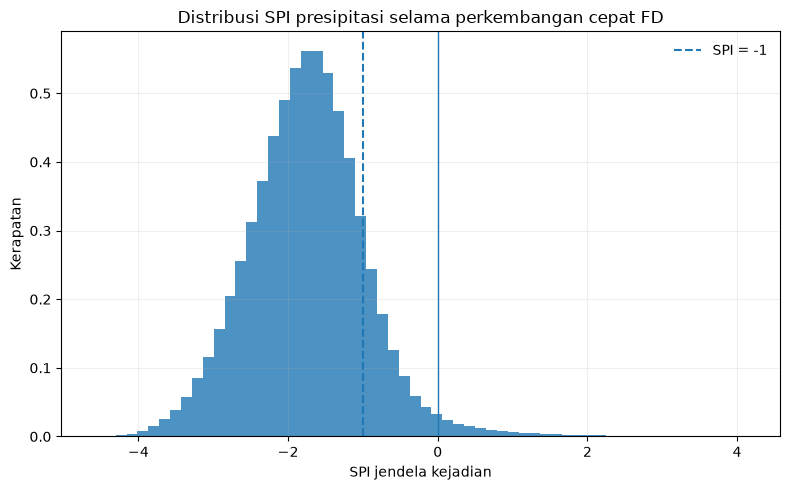

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(valid_events["spi_dev"], bins=60, density=True, alpha=0.8)
ax.axvline(SPI_THRESHOLD, linestyle="--", linewidth=1.5, label="SPI = -1")
ax.axvline(0, linewidth=1.0)
ax.set(
    xlabel="SPI jendela kejadian",
    ylabel="Kerapatan",
    title="Distribusi SPI presipitasi selama perkembangan cepat FD",
)
ax.legend(frameon=False)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure_SPI_event_distribution.png", dpi=250, bbox_inches="tight")
plt.show()


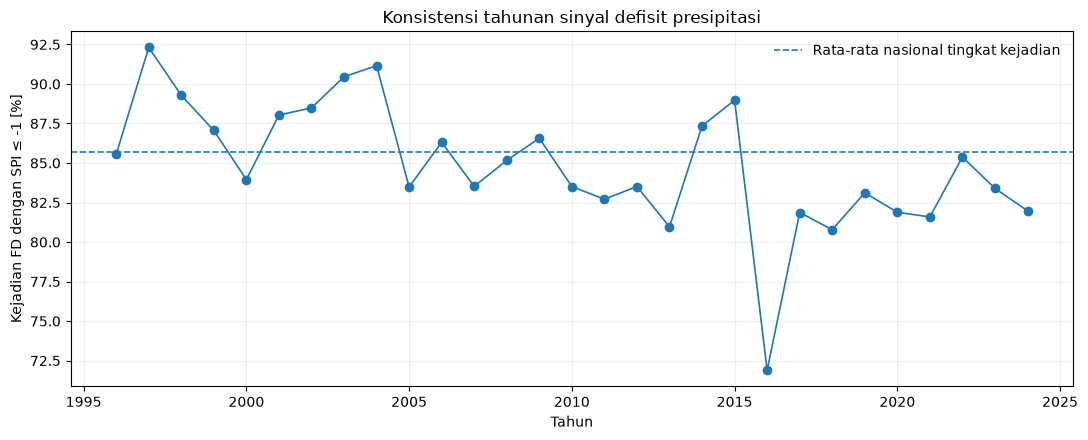

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(
    annual_summary["year"],
    annual_summary["spi_le_minus1_pct"],
    marker="o",
    linewidth=1.2,
)
ax.axhline(
    national_summary.loc[0, "spi_le_minus1_pct"],
    linestyle="--",
    linewidth=1.2,
    label="Rata-rata nasional tingkat kejadian",
)
ax.set(
    xlabel="Tahun",
    ylabel="Kejadian FD dengan SPI ≤ -1 [%]",
    title="Konsistensi tahunan sinyal defisit presipitasi",
)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure_SPI_deficit_fraction_by_year.png", dpi=250, bbox_inches="tight")
plt.show()


## 9. Simpan output

REV1-03 berhenti pada **SPI sebagai diagnostik defisit presipitasi**.

Untuk skripsi/seminar hasil, struktur analisis tetap:

- **RZSM** → deteksi flash drought;
- **P, VPD, T2m** → evolusi/signature meteorologis;
- **SPI event-window** → pemeriksaan tambahan apakah rapid development berasosiasi dengan defisit presipitasi yang secara klimatologis kuat.

Tidak diperlukan data tambahan untuk menyelesaikan REV1-03.


In [13]:
event_out = OUTPUT_DIR / "event_level_SPI_christian_style.parquet"
national_out = OUTPUT_DIR / "national_SPI_summary.csv"
annual_out = OUTPUT_DIR / "annual_SPI_summary.csv"
onset_out = OUTPUT_DIR / "SPI_summary_by_onset_duration.csv"
qc_group_out = OUTPUT_DIR / "SPI_QC_by_calendar_window.csv"

events_spi.to_parquet(event_out, index=False)
national_summary.to_csv(national_out, index=False)
annual_summary.to_csv(annual_out, index=False)
onset_summary.to_csv(onset_out, index=False)

spi_qc_by_group.to_csv(qc_group_out, index=False)

missing_impact_summary = pd.DataFrame([{
    "missing_total_cube_values": int(missing_count),
    "missing_fraction_pct": float(missing_fraction * 100.0),
    "event_windows_touching_missing": int(event_missing_hits),
    "climatology_period_start": int(CLIM_START),
    "climatology_period_end": int(CLIM_END),
    "all_event_windows_complete": bool(event_missing_hits == 0),
    "all_event_spi_valid": bool(np.isfinite(spi_event).all()),
}])
missing_impact_summary.to_csv(
    OUTPUT_DIR / "SPI_QC_missing_impact.csv",
    index=False,
)

alignment_qc = pd.DataFrame([{
    "n_events": int(len(events)),
    "onset_table_equals_detector": bool(alignment_checks["onset_table_equals_detector"]),
    "crossing_minus_start_equals_onset": bool(alignment_checks["crossing_minus_start_equals_onset"]),
    "crossing_after_start": bool(alignment_checks["crossing_after_start"]),
    "driver_window_definition": "t0+1 through threshold crossing, inclusive",
}])
alignment_qc.to_csv(
    OUTPUT_DIR / "SPI_QC_alignment.csv",
    index=False,
)


manifest = {
    "version": "REV1_03_SPI_SEMHAS_v4_FINAL_QC",
    "analysis_period": [ANALYSIS_START, ANALYSIS_END],
    "climatology_period": [CLIM_START, CLIM_END],
    "loaded_precipitation_period": [LOAD_START, LOAD_END],
    "climatology_note": "1995-2024 used as 30 complete baseline years; 2025 loaded only as cross-year buffer.",
    "rapid_development_alignment_qc": "crossing_index_at_start - time_index == onset_time_pentads for every event",
    "event_input": str(event_source),
    "detection_file": str(DETECTION_FILE),
    "precipitation_dir": str(PRECIP_DIR),
    "precipitation_variable": P_VAR,
    "row_definition": "one row = one grid-cell M2A flash-drought start",
    "fd_detection_role": "RZSM benchmark only; SPI is a post-detection driver diagnostic",
    "driver_window": (
        "pentads after RZSM baseline through first <P20 threshold crossing; "
        "length = onset_time_pentads"
    ),
    "spi_type": "event-window SPI",
    "spi_distribution": "gamma with zero-precipitation correction",
    "spi_large_deficit_threshold": SPI_THRESHOLD,
    "minimum_climatology_samples": MIN_CLIM_SAMPLES,
    "missing_precipitation_policy": (
        "Missing precipitation is never treated as zero. Event/climatology windows "
        "are valid only when all pentads in the window are present; incomplete "
        "climatology samples are omitted grid-wise."
    ),
    "reference_method": (
        "Adapted from Christian et al. (2021) driver analysis: accumulated "
        "precipitation over each flash-drought development time frame and SPI "
        "calculated against climatology over the same time frame."
    ),
    "reference_doi": "10.1038/s41467-021-26692-z",
    "interpretation": (
        "precipitation-supply diagnostic association; not causal attribution"
    ),
    "future_merge": (
        "REV1-04 should combine spi_dev with standardized FAO-56 PET anomaly "
        "using the identical event window."
    ),
}

(OUTPUT_DIR / "manifest_REV1_03_SPI_v2_FIXED.json").write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)

print("DONE")
print("Tabel kejadian tersimpan:", event_out)
print("Ringkasan tersimpan di:", OUTPUT_DIR)


DONE
Tabel kejadian tersimpan: D:\ERA5_LAND\output_fd_REV1_03_SPI\event_level_SPI_christian_style.parquet
Ringkasan tersimpan di: D:\ERA5_LAND\output_fd_REV1_03_SPI


# STOP DI SINI — REV1-03 SEMHAS

Setelah notebook selesai dijalankan, periksa terutama:

1. `SPI_QC_alignment.csv`
   - semua nilai audit harus `True`;
2. `SPI_QC_missing_impact.csv`
   - `event_windows_touching_missing` harus `0`;
   - `all_event_windows_complete` harus `True`;
   - `all_event_spi_valid` idealnya `True`;
3. `national_SPI_summary.csv`
   - jumlah event dan proporsi `SPI <= -1`;
4. `SPI_summary_by_onset_duration.csv`
   - memastikan hasil tidak berasal hanya dari satu panjang onset;
5. `SPI_QC_by_calendar_window.csv`
   - `min_valid_clim_samples_grid` harus tetap memenuhi guardrail `>=25`.

Jika lima QC tersebut lolos, REV1-03 dapat dibekukan untuk seminar hasil sebagai analisis tambahan defisit presipitasi.
